In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

In [2]:
X = np.load("../X_data.npy")
y = np.load("../y_gesture.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (747, 100, 64)
y shape: (747,)


In [3]:
gesture_names = {
    0: "bend",
    1: "forward_kick",
    2: "hand_clap",
    3: "horizontal_arm_wave",
    4: "sit_down",
    5: "squat",
    6: "still",
    7: "two_hands_wave",
    8: "walk"
}

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (597, 100, 64)
Test: (150, 100, 64)


In [5]:
num_classes = len(np.unique(y))

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(y_train_cat.shape)

(597, 9)


In [6]:
model = Sequential([
    
    Conv1D(
        32,
        kernel_size=3,
        activation='relu',
        input_shape=(100,64)
    ),
    
    MaxPooling1D(pool_size=2),

    Conv1D(
        64,
        kernel_size=3,
        activation='relu'
    ),

    MaxPooling1D(pool_size=2),

    LSTM(64),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/opt/anaconda3/envs/csi_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-18 13:44:56.773857: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-18 13:44:56.773894: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-18 13:44:56.773899: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-18 13:44:56.774231: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-18 13:44:56.774274: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.c

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 98, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 49, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 47, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,153 (195.91 KB)

 Trainable params: 50,153 (195.91 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30,
    batch_size=16
)

Epoch 1/30


2026-05-18 13:44:57.505435: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.1055 - loss: 2.3089 - val_accuracy: 0.1133 - val_loss: 2.2049
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.0955 - loss: 2.2724 - val_accuracy: 0.1000 - val_loss: 2.2140
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.1089 - loss: 2.2385 - val_accuracy: 0.0867 - val_loss: 2.2089
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.1206 - loss: 2.2110 - val_accuracy: 0.1600 - val_loss: 2.1972
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1307 - loss: 2.2198 - val_accuracy: 0.1000 - val_loss: 2.2437
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1357 - loss: 2.1961 - val_accuracy: 0.0800 - val_loss: 2.2120
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.1642 - loss: 2.1714 - val_accuracy: 0.1133 - val_loss: 2.2316
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1541 - loss: 2.1804 - val_accuracy: 0.0933 - val_loss: 2.

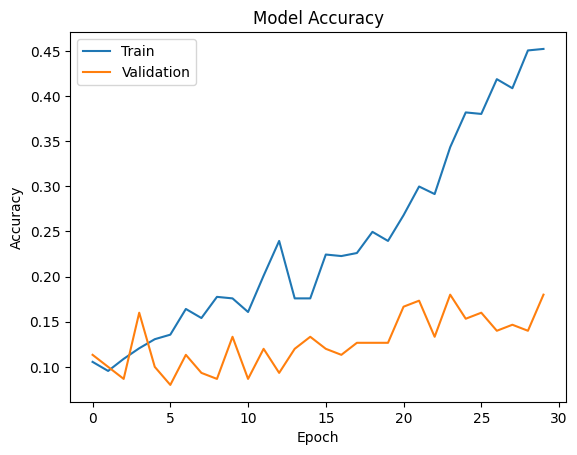

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(['Train', 'Validation'])

plt.show()

In [9]:
loss, acc = model.evaluate(X_test, y_test_cat)

print("Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1800 - loss: 2.5440
Test Accuracy: 0.18000000715255737


In [10]:
predictions = model.predict(X_test)

pred_classes = np.argmax(predictions, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [11]:
cm = confusion_matrix(y_test, pred_classes)

print(cm)

[[8 0 0 0 4 1 2 2 0]
 [4 0 0 0 1 4 2 3 2]
 [3 2 2 0 5 1 1 3 0]
 [5 1 1 4 2 2 1 0 1]
 [6 2 0 0 2 1 1 5 0]
 [2 1 1 2 1 3 1 2 3]
 [3 0 0 1 5 0 4 3 1]
 [4 1 0 0 2 2 2 3 2]
 [4 2 1 1 2 2 0 4 1]]


In [12]:
print(classification_report(
    y_test,
    pred_classes,
    target_names=list(gesture_names.values())
))

                     precision    recall  f1-score   support

               bend       0.21      0.47      0.29        17
       forward_kick       0.00      0.00      0.00        16
          hand_clap       0.40      0.12      0.18        17
horizontal_arm_wave       0.50      0.24      0.32        17
           sit_down       0.08      0.12      0.10        17
              squat       0.19      0.19      0.19        16
              still       0.29      0.24      0.26        17
     two_hands_wave       0.12      0.19      0.15        16
               walk       0.10      0.06      0.07        17

           accuracy                           0.18       150
          macro avg       0.21      0.18      0.17       150
       weighted avg       0.21      0.18      0.17       150

